In [ ]:
import pandas as pd
import numpy as np

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

Data Link: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html

TODO's:
- read up on boxplot interpretation
- read up on how to identify and /or deal with with non-normal features
- review definition of correlation. How is it to be interpreted? How does it differ from covariance?

Notes:
- CHAS is numeric (currently) but should be treated as categorical

Pull Data

In [1]:
url = "https://lib.stat.cmu.edu/datasets/boston"
!curl -O $url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 51256  100 51256    0     0   285k      0 --:--:-- --:--:-- --:--:--  284k


In [15]:
raw_df = pd.read_csv(url, sep=r"\s+", skiprows=22, header=None)

In [16]:
# Combine the two rows per observation
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [17]:
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

In [18]:
# Create the final DataFrame
df = pd.DataFrame(data, columns=columns)
df['MEDV'] = target # Target variable (median house value)

In [19]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [20]:
df.to_csv("./boston_housing.csv", index=False)

CRIM — Per capita crime rate by town

ZN — Proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS — Proportion of non-retail business acres per town

CHAS — Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX — Nitric oxides concentration (parts per 10 million)

RM — Average number of rooms per dwelling

AGE — Proportion of owner-occupied units built prior to 1940

DIS — Weighted distances to five Boston employment centres

RAD — Index of accessibility to radial highways

TAX — Full-value property-tax rate per $10,000

PTRATIO — Pupil-teacher ratio by town

B — 1000(Bk - 0.63)² where Bk is the proportion of Black residents by town

LSTAT — Percentage of lower status of the population


-----
Target Variable (1 variable):

MEDV — Median value of owner-occupied homes in $1,000's (this is what you're trying to predict)

### Read in Data

In [5]:
df = pd.read_csv("./boston_housing.csv")

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Do data exploration

Data Exploration:
- Check data shape and missing values
    - df.isnull().sum() 
- Descriptive statistics:
    - df.describe()
- Distributions of features and target:
    - plot historgrams and check for normality, skew 
- Correlations:
    - Compute correlation matrix: df.corr()
    - Create a heatmap to describe it.
- Relationships between features and target:
    - scatter plot of each feature vs target
    - check if they look linear
    - check for non-linear patters that need transformation
- Check assumptions of linear regression:
    - linearity
    - homoscedasticity
    - outliers


Data Shape & Data Types

In [30]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [7]:
print(df.shape)

(506, 14)


In [8]:
#check that all columns are numeric i.e. no 'object' type data that needs encoding
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


Check for missing values

In [9]:
#check for missing values
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Note: no missing values

**Examine the target variable**

In [35]:
print(df[target].describe())

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


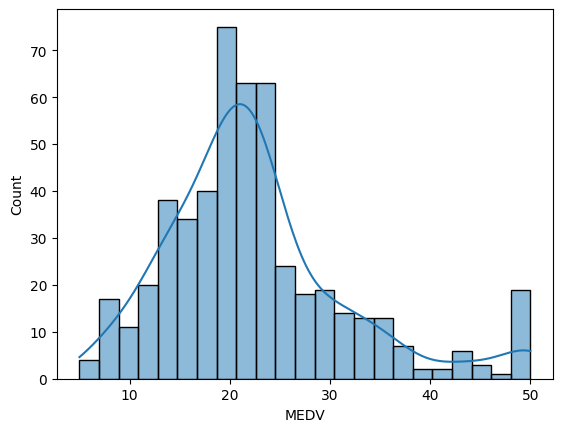

In [38]:
sns.histplot(df[target], kde=True)
plt.show()

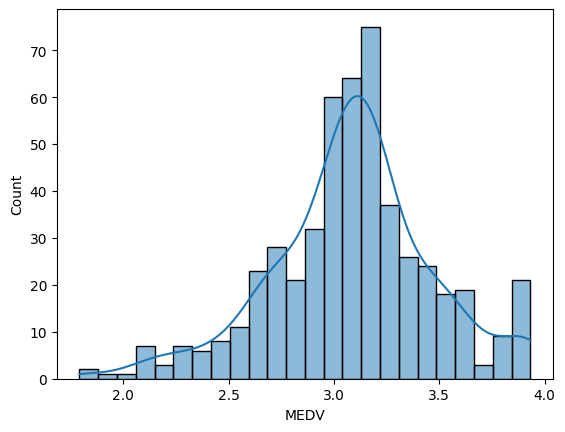

In [39]:
# Is it worth log transforming the target variable?
sns.histplot(np.log1p(df[target]), kde=True)
plt.show()

**Examine numerical features**
- We want to understand: central tendency, spread, and shape. 
- This let's us know if:
    - scaing is needed
    - outliers exist
    - enough variation exists for feature to be used as a predictor

In [41]:
predictors = df.drop(columns=[target])
predictor_cols = predictors.columns

In [42]:
predictors.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


Note: it might be a good idea to normalize the features

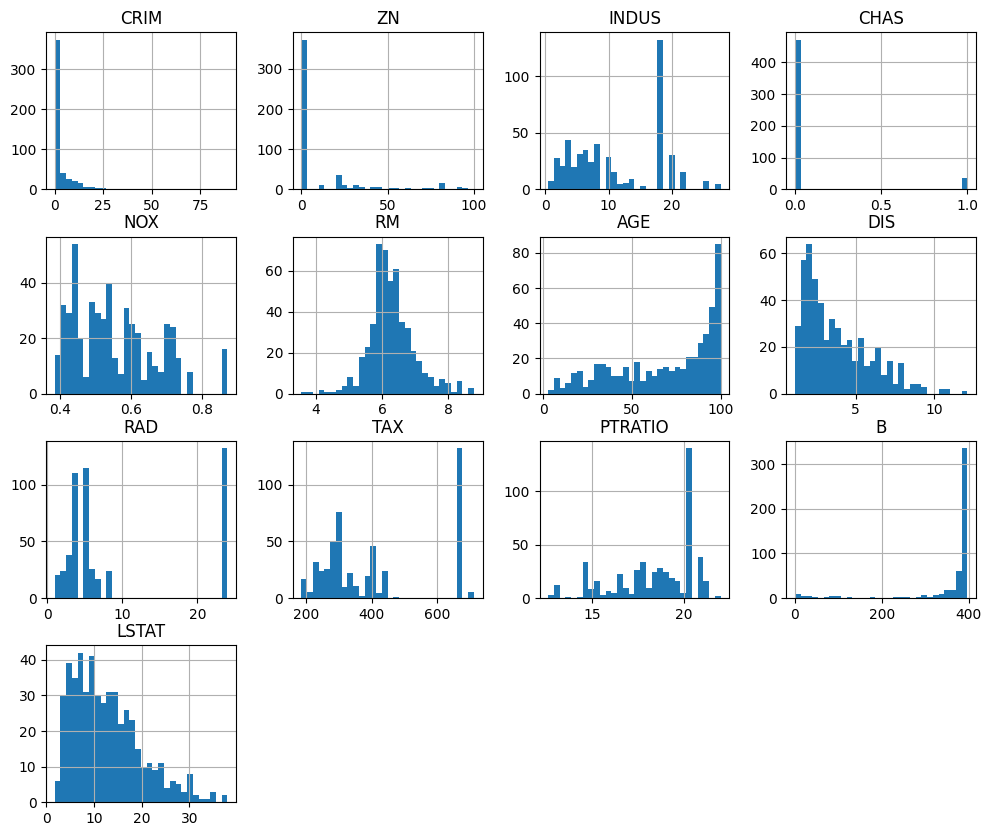

In [43]:
predictors.hist(figsize=(12, 10), bins=30)
plt.show()

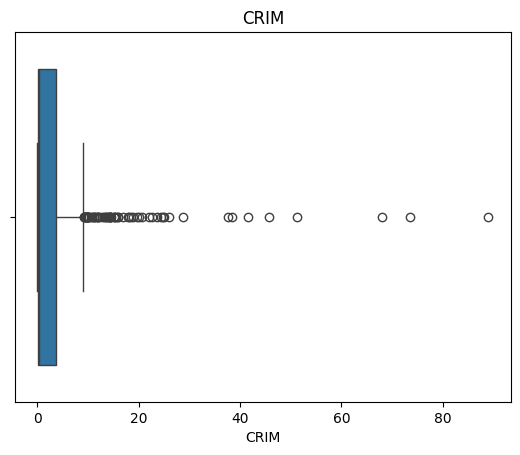

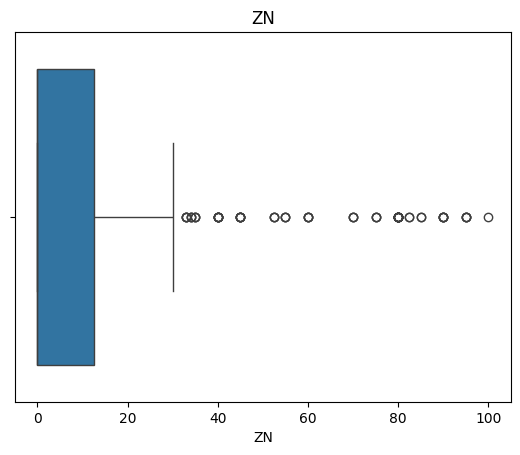

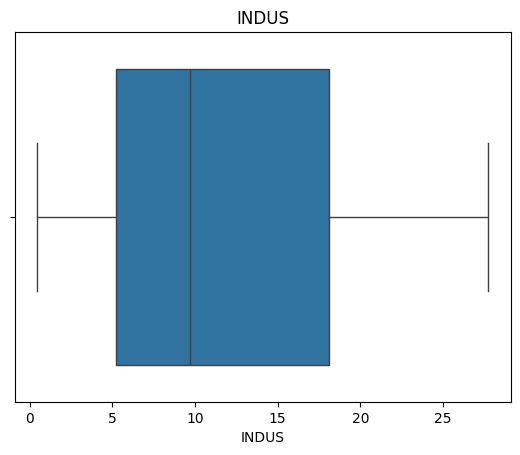

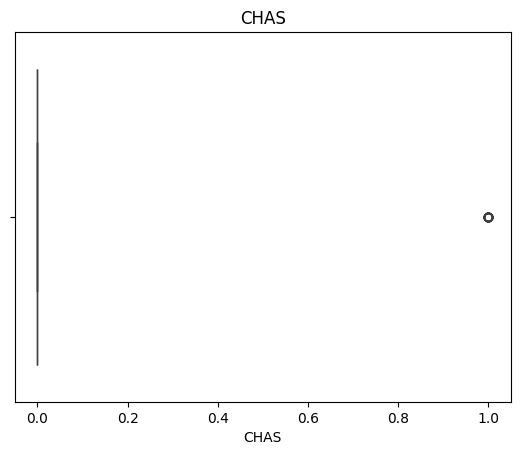

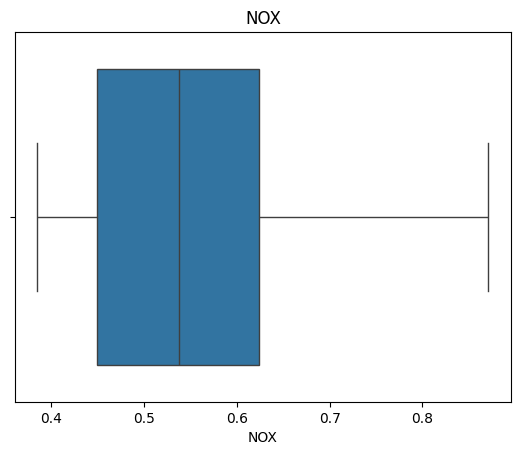

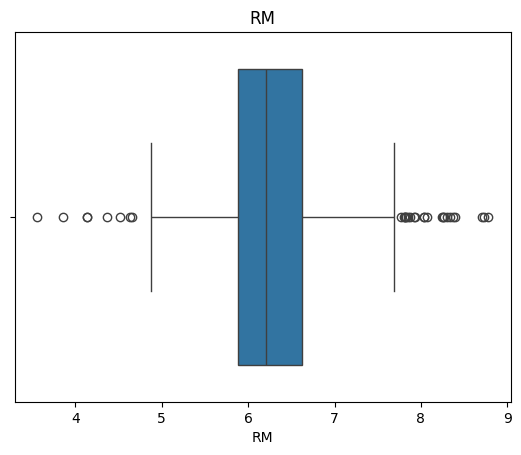

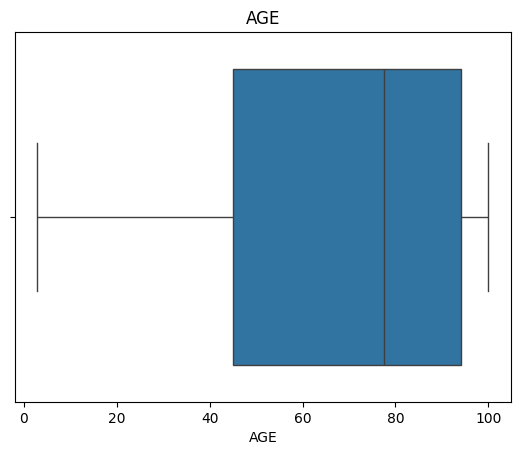

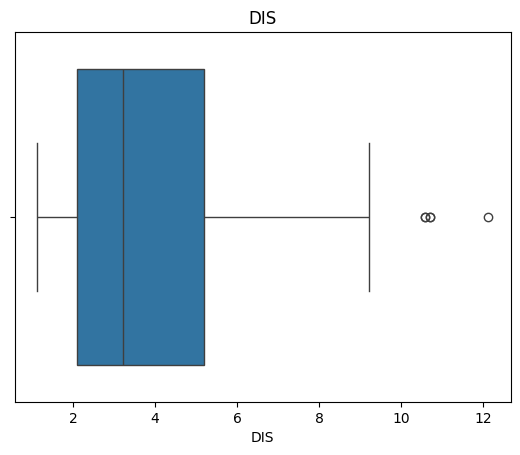

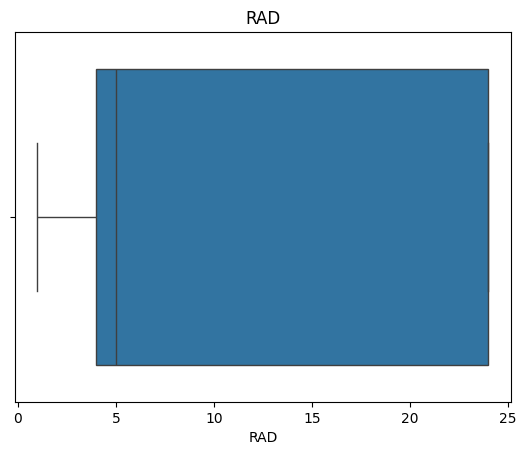

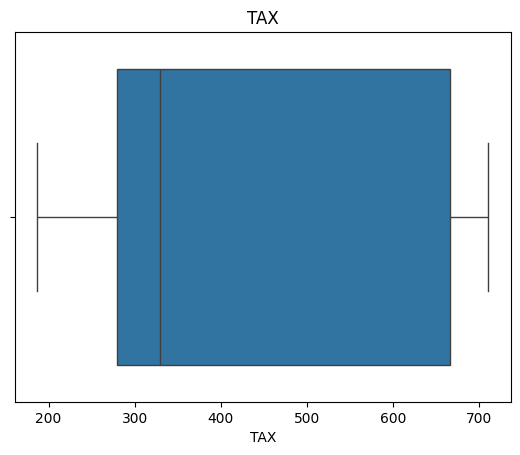

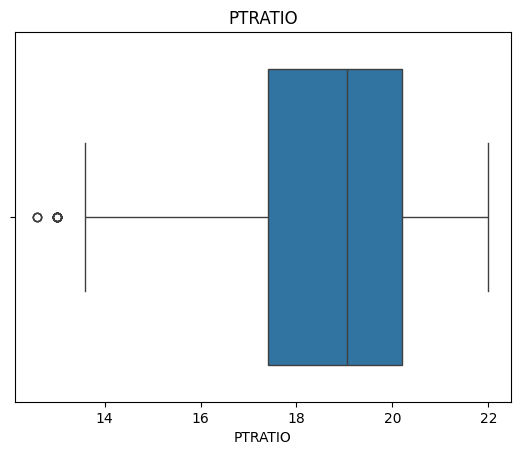

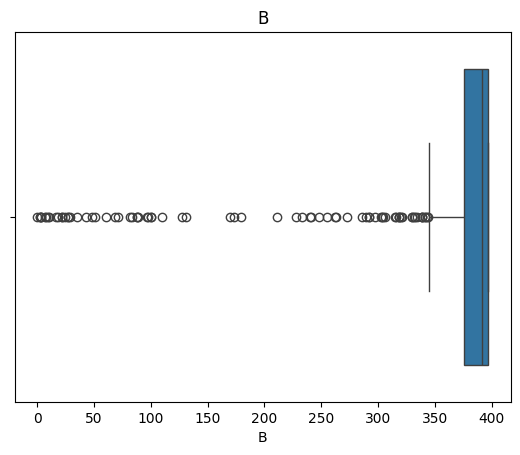

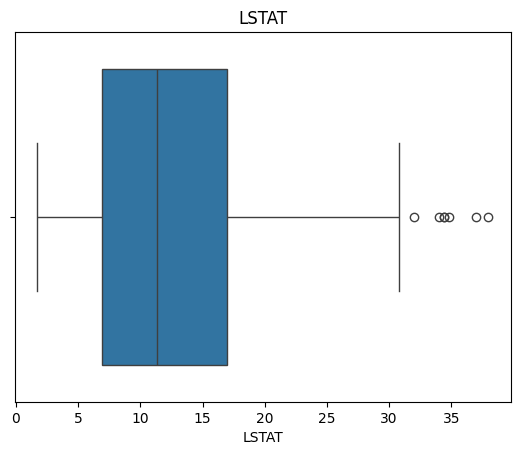

In [44]:
for col in predictor_cols:
    sns.boxplot(x=df[col])
    plt.title(f"{col}")
    plt.show()

**Examine relationship of features to the target**

In [46]:
df.corr()[target].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

In [49]:
df.groupby("CHAS")[target].mean().sort_values(ascending=False)

CHAS
1.0    28.440000
0.0    22.093843
Name: MEDV, dtype: float64

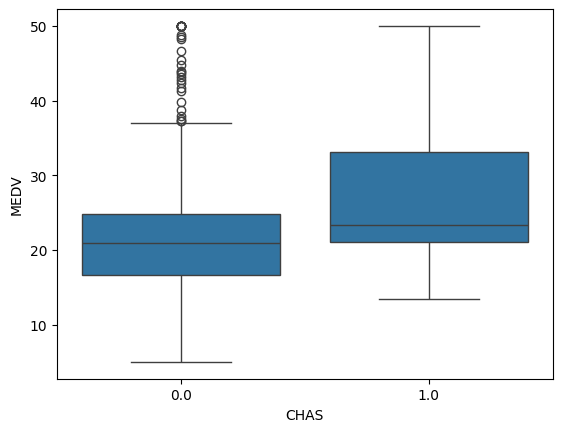

In [48]:
sns.boxplot(x="CHAS", y=target, data=df)
plt.show()

**Examine feature-to-feature relationships**
- checking for highly correlated i.e. redundant features

In [51]:
corr_matrix = df.corr()
corr_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


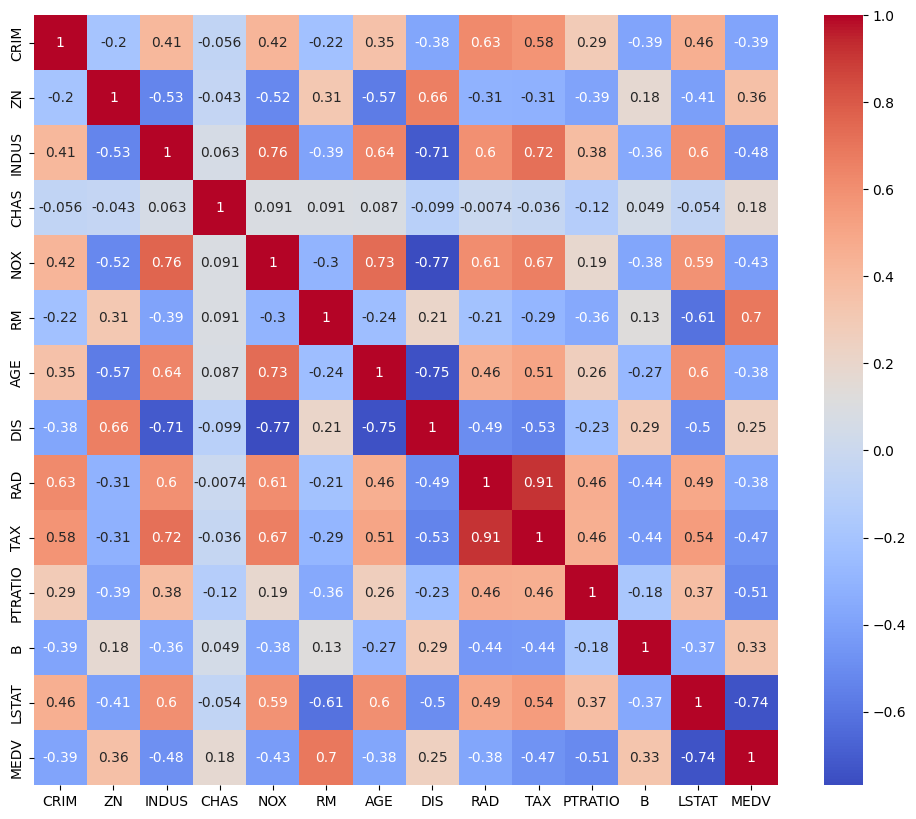

In [55]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

Questions (for later):
- which features are correlated - what do these mean?
- can I map this data graphically i.e. using GIS actual maps?
- might I be able to generalize learings from this data to other cities?

**data quaity checks**
- check for duplicated rows, inconsistent formats, etc

In [56]:
df.duplicated().sum()

0

### Prepare Data For PyTorch

Doing only minimal processing since goal of exercise is just simple regression and to get hands-on experience with PyTorch

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [91]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X_raw)

In [93]:
X.head(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98


In [94]:
print(X.shape, y.shape)

(506, 13) (506,)


In [95]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train_df.shape, X_test_df.shape, y_train_df.shape, y_test_df.shape)

(404, 13) (102, 13) (404,) (102,)


In [96]:
X_test_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04
274,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53
491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07
72,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
452,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27


In [97]:
y_test_df.head()

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
Name: MEDV, dtype: float64

### Build Model

In [98]:
import torch
import torch.nn as nn

Showing both methods of converting from pandas -> numpy -> tensor

In [99]:
# with torch.tensor()
X_test_raw = torch.tensor(X_test_df.values, dtype=torch.float32)
X_train_raw = torch.tensor(X_train_df.values, dtype=torch.float32)

# with torch.from_numpy()
y_test = torch.from_numpy(y_test_df.values).float().view(-1, 1)
y_train = torch.from_numpy(y_train_df.values).float().view(-1, 1)

Normalize X_test_raw

In [111]:
X_train = torch.tensor(scaler.fit_transform(X_train_raw), dtype=torch.float32)

In [112]:
type(X_train)

torch.Tensor

In [114]:
len(X_train[0])

13

Model definition
- Define the model, loss function and optimizer

In [126]:
# Linear model with 13 input features and 1 output feature
model = nn.Linear(13, 1)

# Mean Squared Error (MSE) loss function
criterion = nn.MSELoss()

# Stochastic Gradient Descent (SGD) optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

Run training loop

In [127]:
n_epochs = 10000
losses = []

In [128]:
for epoch in range(n_epochs):

    optimizer.zero_grad()  # Zero the gradients

    # Forward pass: Compute predicted y by passing x to the model
    y_out = model(X_train)

    # Compute the loss
    loss = criterion(y_out, y_train)
    losses.append(loss.item())

    # Backward pass: Compute gradients
    loss.backward()

    # Update weights
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}")

Epoch [500/10000], Loss: 97.2656
Epoch [1000/10000], Loss: 33.0147
Epoch [1500/10000], Loss: 24.0486
Epoch [2000/10000], Loss: 22.6174
Epoch [2500/10000], Loss: 22.2711
Epoch [3000/10000], Loss: 22.1147
Epoch [3500/10000], Loss: 22.0129
Epoch [4000/10000], Loss: 21.9385
Epoch [4500/10000], Loss: 21.8822
Epoch [5000/10000], Loss: 21.8388
Epoch [5500/10000], Loss: 21.8049
Epoch [6000/10000], Loss: 21.7781
Epoch [6500/10000], Loss: 21.7565
Epoch [7000/10000], Loss: 21.7391
Epoch [7500/10000], Loss: 21.7248
Epoch [8000/10000], Loss: 21.7130
Epoch [8500/10000], Loss: 21.7031
Epoch [9000/10000], Loss: 21.6948
Epoch [9500/10000], Loss: 21.6878
Epoch [10000/10000], Loss: 21.6817


Inspect model parameters

In [131]:
w = model.weight.data.numpy()
b = model.bias.data.numpy()

print(f"Weight: {w}, , \nBias: {b}")

Weight: [[-0.95441175  0.59357023  0.10682688  0.7422853  -1.9244256   3.197364
  -0.19243701 -2.9941185   1.7428514  -1.227049   -2.0074418   1.129107
  -3.5930693 ]], , 
Bias: [22.79606]


In [132]:
pd.DataFrame(
    data= w,
    columns=predictor_cols
)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.954412,0.59357,0.106827,0.742285,-1.924426,3.197364,-0.192437,-2.994118,1.742851,-1.227049,-2.007442,1.129107,-3.593069


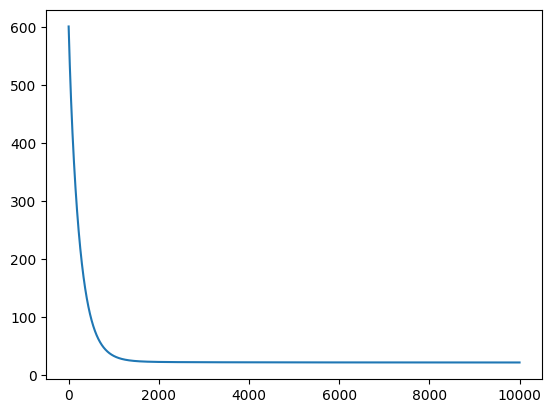

In [134]:
plt.plot(losses)

TODO (self-project, seperate from homework): test out model on X_test